In [41]:
# dsmceq - Dilute gas simulation using DSMC algorithm
# This version illustrates the approach to equilibrium

# Set up configuration options and special features
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [42]:
from nm4p.dsmc import sortList
from nm4p.dsmc import sorter
from nm4p.dsmc import colider

In [43]:
#* Initialize constants  (particle mass, diameter, etc.)
boltz = 1.3806e-23     # Boltzmann's constant (J/K)
mass = 6.63e-26        # Mass of argon atom (kg)
diam = 3.66e-10        # Effective diameter of argon atom (m)
T = 273.               # Temperature (K)
density = 1.78         # Density of argon at STP (kg/m^3)
L = 1.e-6              # System size is one micron
npart = 10000
eff_num = density/mass * L**3 /npart
print('Each particle represents ', eff_num, ' atoms')

Each particle represents  2684.766214177979  atoms


In [44]:
#* Assign random positions and velocities to particles
np.random.seed(0)          # Initialize random number generator
x = np.empty(npart)
for i in range(npart) :
    x[i] = np.random.uniform(0.,L)    # Assign random positions
v_init = np.sqrt(3*boltz*T/mass)      # Initial speed
v = np.zeros((npart,3))     
for i in range(npart) :       # Only x-component is non-zero
    v[i,0] = v_init * (1 - 2*np.floor(2*np.random.random()))

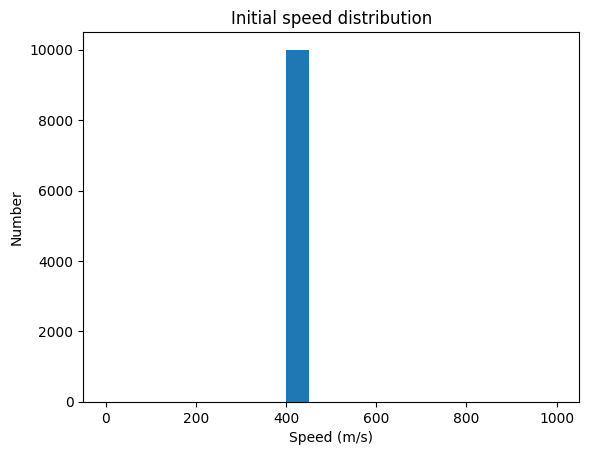

In [45]:
#* Plot the initial speed distribution
vmag = np.sqrt( v[:,0]**2 + v[:,1]**2 + v[:,2]**2 )
plt.hist( vmag, bins=20, range=(0,1000))
plt.title('Initial speed distribution')
plt.xlabel('Speed (m/s)')
plt.ylabel('Number')
plt.show()

In [46]:
#* Initialize variables used for evaluating collisions
ncell = 15                      # Number of cells
tau = 0.2*(L/ncell)/v_init      # Set timestep tau
vrmax = 3*v_init*np.ones(ncell)    # Estimated max rel. speed
selxtra = np.zeros(ncell)          # Used by routine "colider"
coeff = 0.5*eff_num*np.pi*diam**2*tau/(L**3/ncell)
coltot = 0                      # Count total collisions

#* Declare sortList object for lists used in sorting
sortData = sortList(ncell, npart)

  0%|          | 0/2001 [00:00<?, ?it/s]

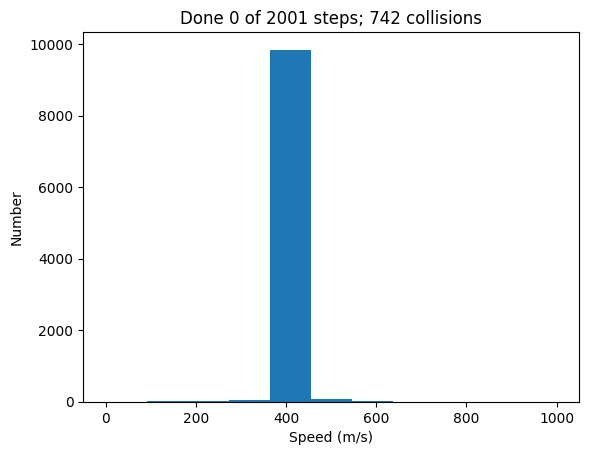

 25%|██▍       | 499/2001 [00:31<01:39, 15.10it/s]

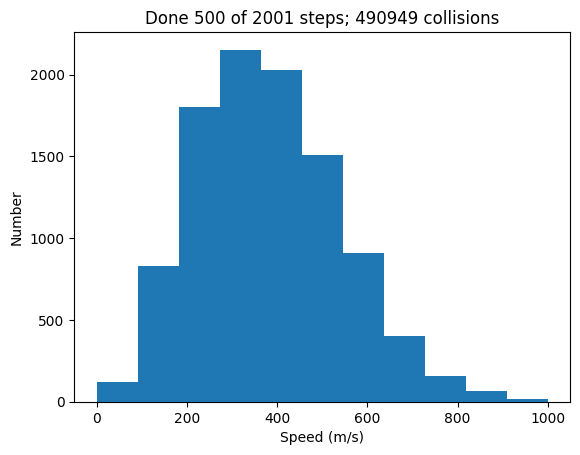

 50%|████▉     | 999/2001 [01:02<01:00, 16.50it/s]

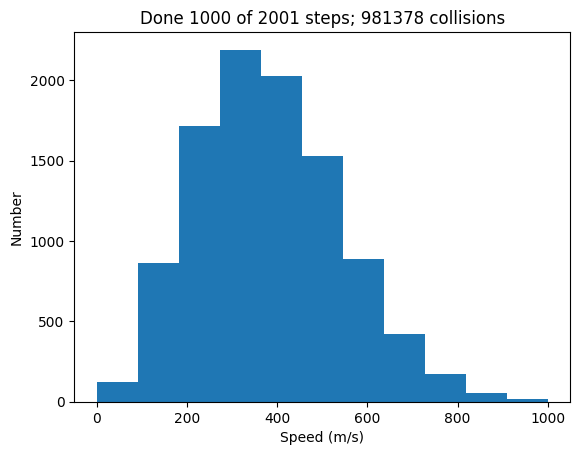

 75%|███████▍  | 1499/2001 [01:32<00:28, 17.43it/s]

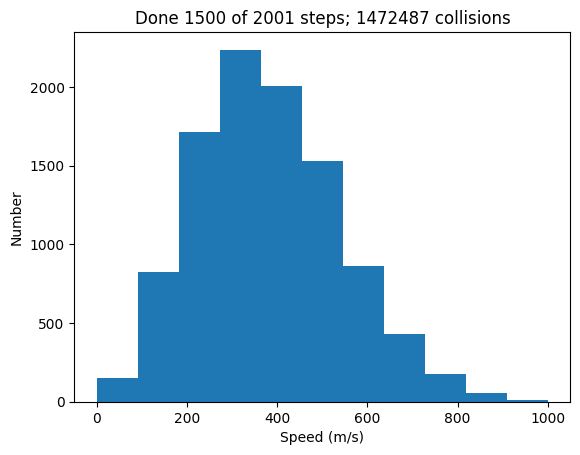

100%|█████████▉| 1999/2001 [02:02<00:00, 16.47it/s]

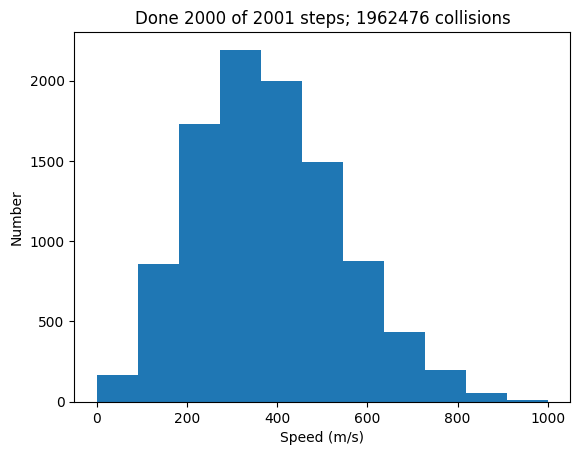

100%|██████████| 2001/2001 [02:03<00:00, 16.27it/s]


In [47]:
#* Loop for the desired number of time steps
nsteps = 2001
for istep in tqdm.trange(nsteps) :

    #* Move all the particles ballistically
    x = x + v[:,0]*tau          # Update x position of particle
    x = np.remainder( x+L, L)   # Periodic boundary conditions

    #* Sort the particles into cells
    sorter(x,L,sortData);
  
    #* Evaluate collisions among the particles
    col = colider(v,vrmax,tau,selxtra,coeff,sortData)
    coltot = coltot + col 
  
    #* Periodically display the current progress
    if (istep) % 500 == 0 :
        vmag = np.sqrt( v[:,0]**2 + v[:,1]**2 + v[:,2]**2 )
        plt.hist( vmag, bins=11, range=(0,1000))
        plt.title('Done %d of %d steps; %d collisions' % (istep, nsteps, coltot))
        plt.xlabel('Speed (m/s)')
        plt.ylabel('Number')
        plt.show()

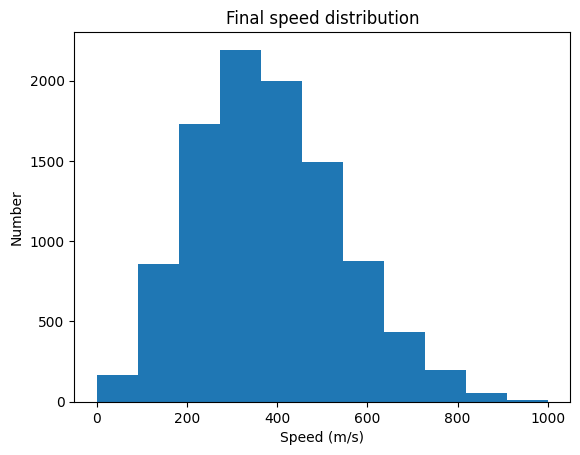

In [48]:
#* Plot the initial speed distribution\n",
vmag = np.sqrt( v[:,0]**2 + v[:,1]**2 + v[:,2]**2 )
plt.hist( vmag, bins=11, range=(0,1000))
plt.title('Final speed distribution')
plt.xlabel('Speed (m/s)')
plt.ylabel('Number')
plt.show()